In [1]:
import sys
import gmsh
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, io, plot
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element, mixed_element
from petsc4py import PETSc

from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, rhs, sym, sqrt,
                 TestFunctions, TrialFunctions, CellDiameter)


In [2]:
meshfile = Path("/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh").resolve()

In [3]:
# Future task: into a helper function
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.open(str(meshfile))

phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

print(name_to_id)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1600 nodes
Info    : 3208 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}


In [4]:
domain, cell_tags, facet_tags = io.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)

coords = domain.geometry.x
x_lim, y_lim = np.max(coords[:, 0]), np.max(coords[:, 1])

# Function spaces for v and p
elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

V = fem.functionspace(domain, elem_u)
Q = fem.functionspace(domain, elem_p)

topology, cell_type, geom = plot.vtk_mesh(V) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

# Temporal parameters
t = 0.0
T = 10.0
dt = 0.01
num_steps = int((T-t)/dt)
time_steps = np.arange(t, T, dt)

# Trial and test functions
u = TrialFunction(V)
v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

# Functions
u_n = Function(V)
u_tent = Function(V)
u_new = Function(V)
p_n = Function(Q)
p_new = Function(Q)
f = Constant(domain, PETSc.ScalarType((0.0, 0.0)))

# Define strain-rate tensor
def epsilon(u):
    return sym(nabla_grad(u))

# Define stress tensor
def sigma(u, p):
    return 2 * mu * epsilon(u) - p * Identity(len(u))

u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(domain)
f = Constant(domain, PETSc.ScalarType((0, 0)))
k = Constant(domain, PETSc.ScalarType(dt))
nu = Constant(domain, PETSc.ScalarType(1.5e-4)) # kinematic viscosity
rho = Constant(domain, PETSc.ScalarType(1.2)) # density
mu = nu * rho # dynamic viscosity

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1600 nodes
Info    : 3208 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


In [5]:
# Define the variational problem for the first step
p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(nu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx

a1 = form(lhs(F1))
L1 = form(rhs(F1))

# Define variational problem for step 2
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_new) * q * dx)

# Define variational problem for step 3
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_new, v) * dx - k * dot(nabla_grad(p_new - p_n), v) * dx)


In [6]:
fdim = V.mesh.topology.dim - 1

# No slip conditions
zero_velocity = Function(V)
zero_velocity.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
# no_slip_names = ["Walls"]

mesh_ids = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological(V, fdim, mesh_ids)
no_slip_bc = fem.dirichletbc(zero_velocity, dofs)

# Inflow boundary
inflow_facets = facet_tags.find(name_to_id["Inflow"])
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)

def parabolic_inflow_profile(x: np.ndarray) -> np.ndarray:
    v_x = 4.0*(x[1]/y_lim)*(1.0 - x[1]/y_lim) * np.ones_like(x[0])
    v_y = np.zeros_like(x[1]) 

    return np.stack((v_x, v_y))

inflow_profile = Function(V)
inflow_profile.interpolate(parabolic_inflow_profile)

bc_in = fem.dirichletbc(inflow_profile, inflow_dofs)

# Outflow
zero_pressure = Function(Q)
zero_pressure.x.array[:] = 0.0
outflow_dofs = fem.locate_dofs_topological(Q, fdim, facet_tags.find(name_to_id["Outflow"]))

bc_out = fem.dirichletbc(zero_pressure, outflow_dofs)

# bcs summary
velocity_bcs = [bc_in, no_slip_bc]
pressure_bcs = [bc_out]

Converged after 12 iterations.
Final L2 err = 2.21e-09


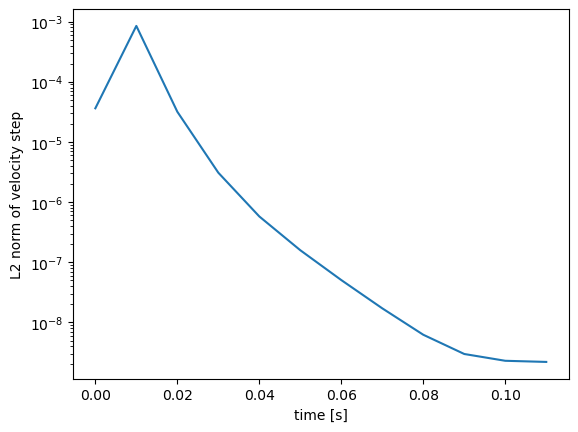

In [7]:
# Set up and solve
tentative_velocity_problem = LinearProblem(a1, L1, velocity_bcs, u_tent, 
                                           petsc_options={"ksp_type": "gmres"})
pressure_problem = LinearProblem(a2, L2, pressure_bcs, p_new)
velocity_correction_problem = LinearProblem(a3, L3, velocity_bcs, u_new)

# Error form
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V) 
l2_norm_squared = form(inner(u_diff, u_diff) * dx)
l2_errors = np.zeros(num_steps)
it_conv = np.inf

for idx, t_i in enumerate(time_steps):
    t = t_i
    tentative_velocity_problem.solve()
    pressure_problem.solve()
    velocity_correction_problem.solve()
    u_diff.x.array[:] = u_new.x.array - u_n.x.array
    l2_errors[idx] = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    
    if t_i > time_steps[0]:
        if abs(l2_errors[idx] - l2_errors[idx - 1]) < 1e-10:
            it_conv = idx
            print(f"Converged after {idx + 1} iterations.")
            print(f"Final L2 err = {l2_errors[it_conv]:.2e}")
            
            break
    u_n.x.array[:] = u_new.x.array
    p_n.x.array[:] = p_new.x.array
    sys.stdout.flush()


if it_conv == np.inf:
    print(f"Reached max number of iterations. L2 Error: {l2_errors[-1]:.2e}")

if it_conv == np.inf:
    plt.semilogy(time_steps, l2_errors)
else:
    plt.semilogy(time_steps[0:it_conv+1], l2_errors[0:it_conv+1])
plt.xlabel("time [s]")
plt.ylabel("L2 norm of velocity step")
sys.stdout.flush()


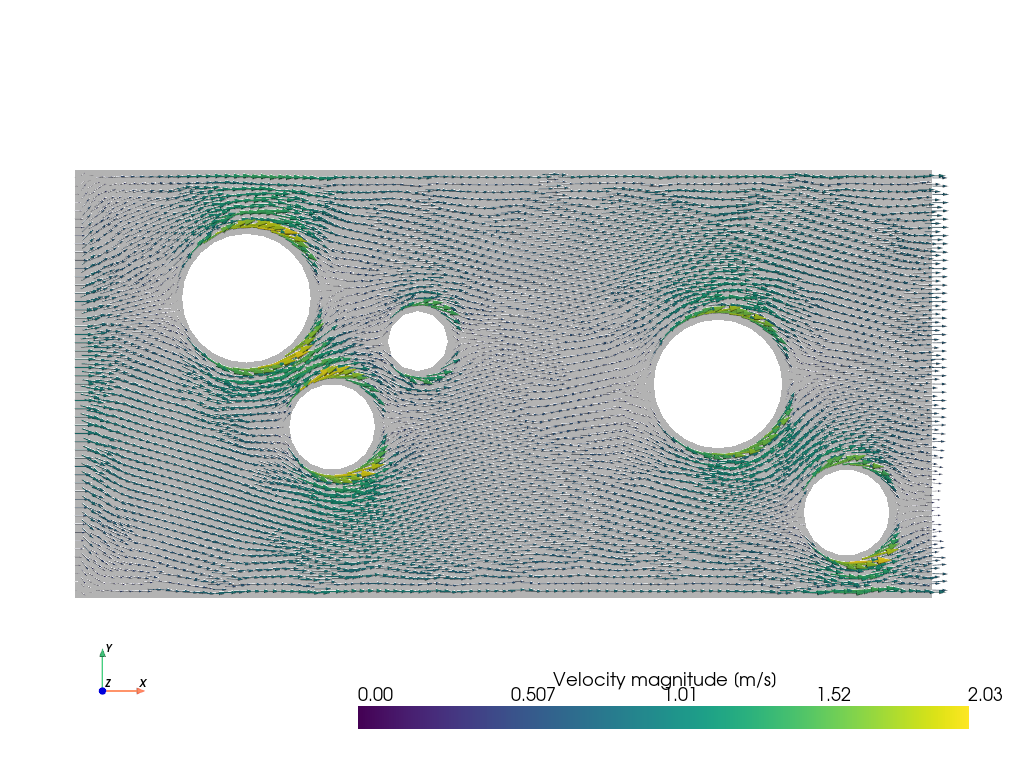

In [8]:
# Visualize solution
dom_cell = domain.basix_cell()
V_u_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))

u_vis = Function(V_u_vis)
u_vis.interpolate(u_new)

# Visualize
wind2d = u_new.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
wind_plot_indices = np.arange(0, grid.n_points, 1) # less dense plot
subset = grid.extract_points(wind_plot_indices, include_cells=False)
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.5)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Velocity magnitude [m/s]"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.zoom_camera(1.3)
pl.show_axes()
pl.show()

In [9]:
# Save file
import adios4dolfinx

wind_file = Path("/home/dominik/git/dispersion_sim/wind_data/airflow_ipcs.bp")
adios4dolfinx.write_mesh(wind_file, domain)
adios4dolfinx.write_meshtags(wind_file, domain, facet_tags, meshtag_name="facet_tags")
adios4dolfinx.write_function(wind_file, u_new, name="velocity_H2")